In [1]:
import pandas as pd
import requests
import numpy as np
from bs4 import BeautifulSoup

In [2]:
url='https://www.myntra.com/dresses?f=Gender%3Amen%20women%2Cwomen'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml"
}

session = requests.Session()
print("starting")
dresses = session.get(url,headers=headers,timeout=15)

print("done")
print(dresses.status_code)

starting
done
200


In [4]:
soup= BeautifulSoup(dresses.text,'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Dresses Online - Low Price Offer on Dresses for Women at Myntra
  </title>
  <meta content="#fffff" name="theme-color"/>
  <link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/>
  <link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/>
  <link href="https://www.facebook.com" rel="dns-prefetch preconnect"/>
  <link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/>
  <link href="/manifest.json" rel="manifest"/>
  <link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/>
  <link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="apple-to
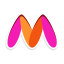

In [5]:
print(soup.prettify())

In [33]:
from selenium import webdriver
from bs4 import BeautifulSoup
import time
driver= webdriver.Chrome()

url = "https://www.myntra.com/dresses?f=Gender%3Amen%20women%2Cwomen"
driver.get(url)

time.sleep(10)
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

items= soup.find_all('li',class_='product-base')
print(len(items))

50


In [34]:
print(items[0].prettify())

<li class="product-base" id="42247657">
 <div class="product-thumbShim">
 </div>
 <a data-refreshpage="true" href="ethnic-dresses/skydyeing/skydyeing-geometric-printed-halter-neck-cotton-fit-and-flare-ethnic-dresses/42247657/buy" style="display: block;" target="_blank">
  <div class="product-imageSliderContainer">
   <div class="product-sliderContainer" style="display: block;">
    <div style="background: rgb(255, 237, 243);">
     <div style="height: 280px; width: 100%;">
      <picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;">
       <source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_limit,fl_progressive/assets/images/2026/MAY/18/badd99YV_d955f8733f154c2ca1d13b95bdeb6901.jpg ,
    https://assets.myntassets.com/f_webp,dpr_1.5,q_60,w_210,c_limit,fl_progressive/assets/images/2026/MAY/18/badd99YV_d955f8733f154c2ca1d13b95bdeb6901.jpg 1.5x,
    https://assets.myntassets.com/f_webp,dpr_1.8,q_60,w_210,c_limit,fl_p

In [35]:
title=[]
rating=[]
rating_count=[]
brand=[]
price=[]
image_urls=[]
size=[]

for i in items:

    t = i.find('h4', class_='product-product')
    title.append(t.text.strip() if t else None)

    r = i.find('div', class_='product-ratingsContainer')
    rating.append(r.text.strip() if r else None)

    rc = i.find('div', class_='product-ratingsCount')
    rating_count.append(rc.text.strip() if rc else None)

    b = i.find('h3', class_='product-brand')
    brand.append(b.text.strip() if b else None)

    s = i.find('h4', class_='product-sizes')
    size.append(s.text.strip() if s else None)

    p = i.find('div', class_='product-price')
    price.append(p.text.strip() if p else None)

    img = i.find("img")
    if img:
        image_urls.append(img.get("src"))
    else:
        image_urls.append(None)

In [36]:
d= {'title':title, 'brand':brand, 'rating':rating, 'price':price, 'size':size, 'rating_count': rating_count, 'image_url':image_urls}

In [37]:
df_dresses=pd.DataFrame(d)

In [38]:
print(df_dresses.shape)

(50, 7)


In [39]:
df_dresses["rating"] = df_dresses["rating"].str.split("|").str[0]
df_dresses["rating_count"] = df_dresses["rating_count"].str.split("|").str[1]

In [40]:
df_dresses["size"] = df_dresses["size"].str.split(":").str[1]
df_dresses["current_price"] = (
    df_dresses["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*(\d+)')
)
df_dresses["original_price"] = (
    df_dresses["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*\d+Rs\.\s*(\d+)')
)
df_dresses["discount"] = (
    df_dresses["price"]
    .astype(str)
    .str.extract(r'\((.*?)\)')
)
df_dresses["category"]= 'dresses'

In [15]:
df_dresses.head()

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount,category
0,Printed Cotton Ethnic Dresses,SKYDYEING,None,Rs. 772Rs. 1999(61% OFF),NaN,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",772,1999,61% OFF,dresses
1,Women Printed Ethnic Dress,Sangria,4.4,Rs. 637Rs. 3999(84% OFF),NaN,22,"https://assets.myntassets.com/dpr_2,q_60,w_210...",637,3999,84% OFF,dresses
2,Georgette A-Line Ethnic Dress,HERE&NOW,None,Rs. 780Rs. 4499(83% OFF),NaN,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",780,4499,83% OFF,dresses
3,Floral Print A-Line Midi Puff Sleeve Dress,KEIYONA,None,Rs. 998Rs. 3299(70% OFF),NaN,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",998,3299,70% OFF,dresses
4,Printed Cotton Ethnic Dresses,SKYDYEING,None,Rs. 778Rs. 1999(61% OFF),NaN,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",778,1999,61% OFF,dresses


In [41]:
df_dresses.head()

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount,category
0,Printed Cotton Ethnic Dresses,SKYDYEING,None,Rs. 772Rs. 1999(61% OFF),M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",772,1999,61% OFF,dresses
1,Women Printed Ethnic Dress,Sangria,4.4,Rs. 637Rs. 3999(84% OFF),XL,22,"https://assets.myntassets.com/dpr_2,q_60,w_210...",637,3999,84% OFF,dresses
2,Round Neck Sheath Midi Dress,U.S. Polo Assn. Women,None,Rs. 1198Rs. 2549(53% OFF),XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1198,2549,53% OFF,dresses
3,Georgette A-Line Ethnic Dress,HERE&NOW,None,Rs. 780Rs. 4499(83% OFF),S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",780,4499,83% OFF,dresses
4,Floral Print A-Line Midi Puff Sleeve Dress,KEIYONA,None,Rs. 998Rs. 3299(70% OFF),M,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",998,3299,70% OFF,dresses


In [42]:
df_dresses.isnull().sum()

title              0
brand              0
rating            28
price              0
size               0
rating_count      28
image_url          0
current_price      0
original_price     0
discount           0
category           0
dtype: int64

In [43]:
df_dresses.drop(columns=["price"], inplace=True)

In [44]:
product_url = []
from urllib.parse import urljoin
for i in items:
    
    a = i.find("a")
    
    if a and a.get("href"):
        link = urljoin("https://www.myntra.com", a["href"])
    else:
        link = None

    product_url.append(link)

In [45]:
df_dresses['product_url']= product_url

In [46]:
df_dresses_copy= df_dresses.copy()

In [47]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_dresses["rating_count"] = df_dresses["rating_count"].apply(convert_count)

In [48]:
df_dresses.sample(5)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
40,Print A-Line Maxi Dress,KEIYONA,None,M,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",998,3299,70% OFF,dresses,https://www.myntra.com/dresses/keiyona/keiyona...
39,Fit & Flared Ethnic Dresses,anayna,4.5,S,11500.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1241,3992,69% OFF,dresses,https://www.myntra.com/ethnic-dresses/anayna/a...
21,Printed Cotton Ethnic Dresses,SKYDYEING,None,M,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",778,1999,61% OFF,dresses,https://www.myntra.com/ethnic-dresses/skydyein...
27,Women Flared Midi Dress,anayna,4.6,3XL,1100.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",1241,4750,74% OFF,dresses,https://www.myntra.com/ethnic-dresses/anayna/a...
9,Maxi Dress With Dupatta,HERE&NOW,None,M,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",780,4499,83% OFF,dresses,https://www.myntra.com/ethnic-dresses/here%26n...


In [49]:
df_dresses["rating"] = pd.to_numeric(df_dresses["rating"], errors="coerce")
df_dresses["current_price"] = pd.to_numeric(df_dresses["current_price"], errors="coerce")
df_dresses["original_price"] = pd.to_numeric(df_dresses["original_price"], errors="coerce")

In [50]:
df_dresses["rating_count"] = df_dresses["rating_count"].fillna(0).astype(int)

In [51]:
df_dresses["original_price"] = (
    df_dresses["original_price"]
    .fillna(0)
    .astype(int)
)

In [52]:
df_dresses["discount_percent"] = (
    (
        df_dresses["original_price"] -
        df_dresses["current_price"]
    )
    / df_dresses["original_price"]
) * 100

In [53]:
df_dresses["discount_percent"] = (
    df_dresses["discount_percent"]
    .round(2)
)

In [54]:
df_dresses = df_dresses.drop("discount", axis=1)

In [55]:
df_dresses['current_price']=df_dresses['current_price'].astype(float)

In [56]:
df_dresses['original_price']= df_dresses['original_price'].astype(float)

In [57]:
df_dresses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            22 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         50 non-null     object 
 6   current_price     50 non-null     float64
 7   original_price    50 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  50 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [58]:
df_dresses.isnull().sum()

title                0
brand                0
rating              28
size                 0
rating_count         0
image_url            0
current_price        0
original_price       0
category             0
product_url          0
discount_percent     0
dtype: int64

In [59]:
df_dresses.to_csv("looped_dresses_data.csv", index=False)